Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("10_loan_approval.csv")

Data Inspection

In [3]:
df.head()

,age,income_lakh,credit_score,loan_amount_lakh,existing_loans,approved
0,28.0,12.64,613.0,8.93,3.0,1
1,57.0,19.80,753.0,28.22,3.0,1
2,35.0,20.54,787.0,18.94,1.0,1
3,59.0,18.87,816.0,11.61,1.0,1
4,62.0,11.63,553.0,5.23,3.0,1


In [4]:
df.describe()

,age,income_lakh,credit_score,loan_amount_lakh,existing_loans,approved
count,1009.000000,1010.000000,1010.000000,1010.000000,1010.000000,1020.000000
mean,42.448959,13.453802,644.527723,15.857168,2.048515,0.664706
std,12.753447,6.949768,119.393453,8.273434,1.423512,0.472325
min,15.000000,-5.000000,450.000000,1.040000,-2.000000,0.000000
25%,31.000000,7.372500,539.000000,8.995000,1.000000,0.000000
50%,42.000000,13.765000,643.000000,15.860000,2.000000,1.000000
75%,53.000000,19.387500,744.750000,22.900000,3.000000,1.000000
max,64.000000,24.990000,1000.000000,29.960000,4.000000,1.000000


Checking the missing values

In [5]:
df.isnull().sum()

,0
age,11
income_lakh,10
credit_score,10
loan_amount_lakh,10
existing_loans,10
approved,0


In [6]:
df[df.isnull().any(axis=1)]

,age,income_lakh,credit_score,loan_amount_lakh,existing_loans,approved
52,34.0,NaN,737.0,1.48,0.0,1
103,26.0,12.57,774.0,2.06,NaN,1
136,52.0,11.72,552.0,NaN,2.0,0
142,58.0,21.21,NaN,3.35,2.0,1
162,NaN,3.67,534.0,8.55,3.0,0
180,52.0,24.53,482.0,NaN,4.0,1
193,44.0,NaN,741.0,21.25,1.0,1
199,55.0,3.23,616.0,14.32,NaN,0
201,NaN,17.79,467.0,25.13,1.0,1
213,51.0,3.65,832.0,14.90,NaN,0


Checking duplicate values

In [7]:
df.duplicated().sum()

np.int64(20)

In [8]:
df[df.duplicated()]

,age,income_lakh,credit_score,loan_amount_lakh,existing_loans,approved
235,36.0,21.27,543.0,24.28,4.0,1
276,48.0,16.21,787.0,15.33,2.0,1
332,58.0,17.97,725.0,19.34,2.0,1
432,39.0,3.34,733.0,9.75,0.0,0
455,48.0,7.72,471.0,15.97,4.0,0
463,34.0,1.53,787.0,26.05,3.0,0
569,64.0,22.53,521.0,22.76,2.0,1
636,22.0,12.73,486.0,11.68,3.0,1
670,47.0,9.37,643.0,21.74,2.0,0
691,58.0,20.82,812.0,26.19,3.0,1


Finding unrealisting ages

In [9]:
df[(df['age'] < 18) | (df['age'] > 100)]

,age,income_lakh,credit_score,loan_amount_lakh,existing_loans,approved
123,15.0,10.15,529.0,22.10,1.0,0
170,15.0,19.44,753.0,24.54,4.0,1
266,15.0,19.45,831.0,27.44,3.0,1
523,15.0,3.52,624.0,17.86,4.0,0
555,15.0,10.64,710.0,18.01,4.0,0


Finding invalid credit scores

In [10]:
df[(df['credit_score'] < 300) | (df['credit_score'] > 850)]

,age,income_lakh,credit_score,loan_amount_lakh,existing_loans,approved
21,48.0,13.17,1000.0,19.20,2.0,1
80,31.0,8.47,1000.0,10.37,2.0,1
225,51.0,22.82,1000.0,24.86,3.0,1
976,48.0,6.57,1000.0,8.04,2.0,1
1003,37.0,16.82,1000.0,25.15,2.0,1


Finding negative income

In [11]:
df[(df['income_lakh']<0)]

,age,income_lakh,credit_score,loan_amount_lakh,existing_loans,approved
20,39.0,-5.0,584.0,21.52,2.0,1
210,60.0,-5.0,476.0,17.56,1.0,1
565,47.0,-5.0,476.0,29.76,1.0,0
739,62.0,-5.0,687.0,6.70,1.0,1
812,31.0,-5.0,822.0,9.01,1.0,1


Finding negative existing loans

In [12]:
df[(df['existing_loans']<0)]

,age,income_lakh,credit_score,loan_amount_lakh,existing_loans,approved
344,34.0,17.10,611.0,12.59,-2.0,1
500,36.0,19.08,490.0,25.68,-2.0,1
573,43.0,11.64,730.0,8.50,-2.0,1
821,35.0,17.91,538.0,5.98,-2.0,1
885,25.0,17.39,746.0,27.63,-2.0,1


Plot of credit-score and income distributions.

/tmp/ipykernel_1830/882164032.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Rejected', 'Approved'])


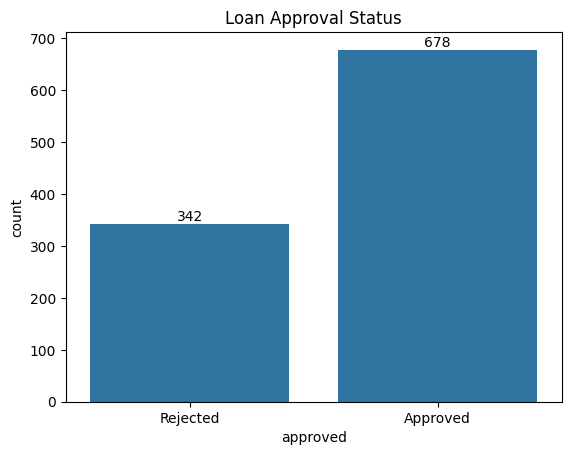

In [13]:
ax = sns.countplot(x='approved', data=df)
ax.set_xticklabels(['Rejected', 'Approved'])
for container in ax.containers:
    ax.bar_label(container)
plt.title('Loan Approval Status')
plt.show()

Plot of credit-score and income distributions.




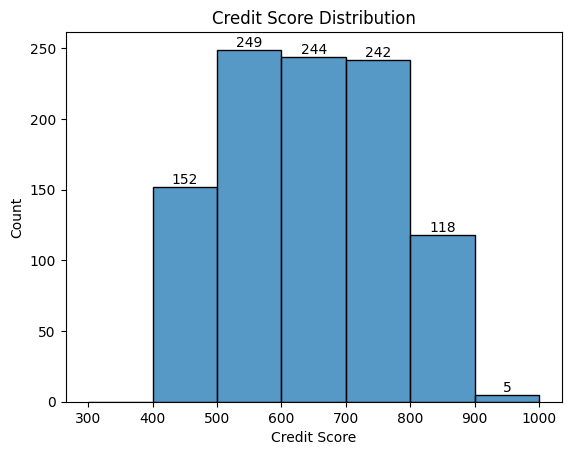

In [14]:
bins = np.arange(300, 1100, 100)

ax = sns.histplot(df['credit_score'], bins=bins)

for bar in ax.patches:
    count = int(bar.get_height())
    if count > 0:ax.text(bar.get_x() + bar.get_width() / 2,count,str(count),ha='center',va='bottom')

plt.title('Credit Score Distribution')
plt.xlabel('Credit Score')
plt.ylabel('Count')
plt.xticks(bins)
plt.show()

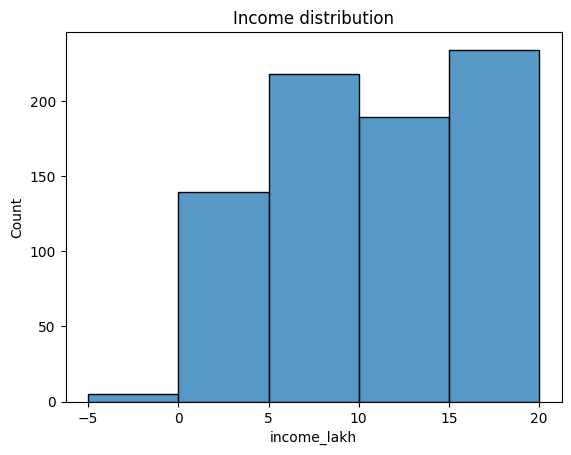

In [15]:
bins = np.arange(-5,25,5)
sns.histplot(df['approval'], bins=bins)
plt.title('Income distribution')
plt.xlabel('income_lakh')
plt.ylabel('Count')
plt.show()

Plot of income credit score vs approval

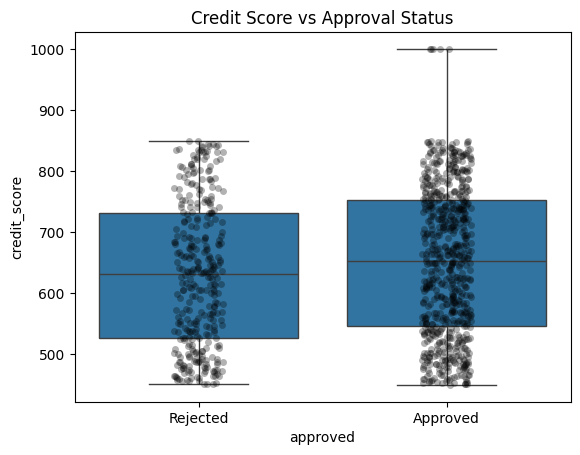

In [16]:
sns.boxplot(x='approved', y='credit_score', data=df)
sns.stripplot(x='approved', y='credit_score', data=df,color='black', alpha=0.3)
plt.xticks([0, 1], ['Rejected', 'Approved'])
plt.title('Credit Score vs Approval Status')
plt.show()

Plot of Income vs approval

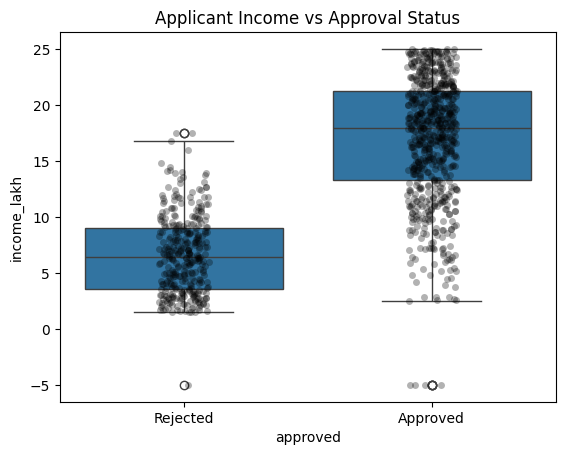

In [17]:
sns.boxplot(x='approved', y='income_lakh', data=df)
sns.stripplot(x='approved', y='income_lakh', data=df,color='black', alpha=0.3)
plt.xticks([0,1], ['Rejected','Approved'])
plt.title('Applicant Income vs Approval Status')
plt.show()

Plot of loan amount vs approval

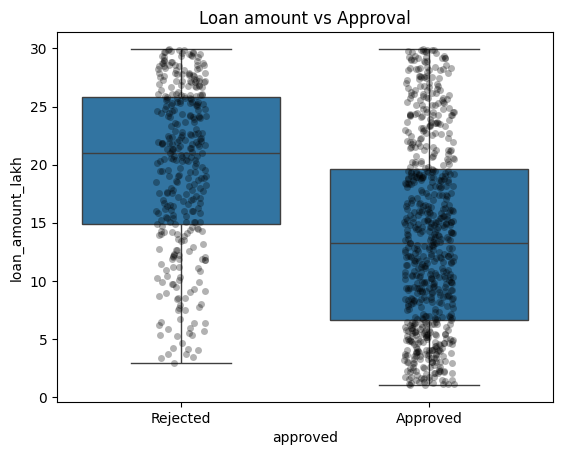

In [18]:
sns.boxplot(x='approved',y='loan_amount_lakh', data=df)
sns.stripplot(x='approved', y='loan_amount_lakh', data=df, color='black', alpha=0.3)
plt.title("Loan amount vs Approval")
plt.xticks([0,1], ['Rejected','Approved'])
plt.show()

Correlation heatmap.

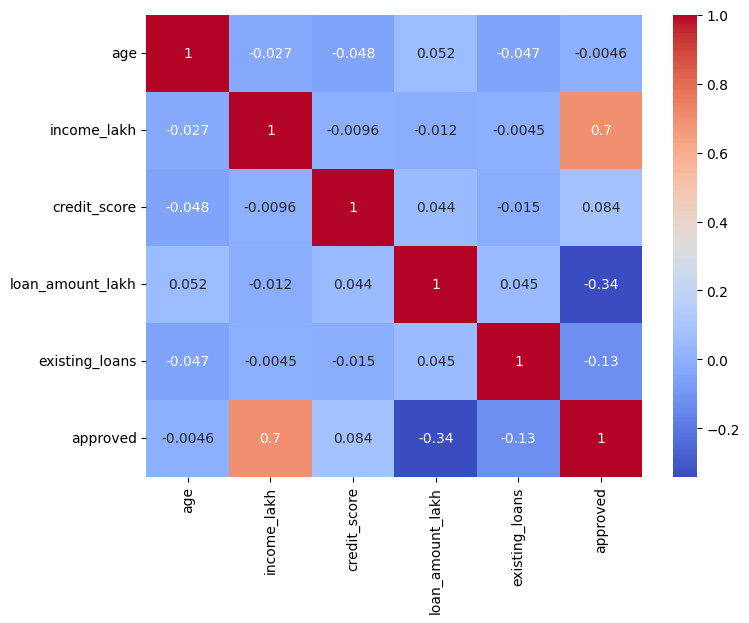

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap( df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()

Cleaning the dataset by removing all the NaN values & duplicate rows

In [20]:
df.fillna(df.mean(numeric_only=True), inplace = True)

In [21]:
df.drop_duplicates(inplace=True)

In [22]:
print(df.shape)

(1000, 6)


In [25]:
df=df[df['age'].between(18,100)]

In [26]:
print(df.shape)

(995, 6)


In [27]:
df=df[df['income_lakh']>0]

In [28]:
print(df.shape)

(990, 6)


In [54]:
df=df[df['credit_score'].between(300,850)]

In [55]:
print(df.shape)

(985, 9)


Creation of Debt burden

In [56]:
df['debt_burden'] = (df['loan_amount_lakh'] /df['income_lakh'])

Creation of a additonal useful feature

In [62]:
df['loan_affordability'] = (df['income_lakh'] /(df['existing_loans'] + 1))

In [63]:
df.groupby('approved')['income_per_loan'].mean()

,income_per_loan
approved,
0,2.534163
1,7.518164


The engineered feature loan_affordability shows a strong relationship with loan approval. Approved applicants have an average loan_affordability value of 7.52, while rejected applicants have an average value of only 2.53. This indicates
that applicants with higher income and fewer existing loans tend to have higher approval rates.

Separation of X and y using "approved" as the target.

In [65]:
X = df.drop('approved', axis=1)

In [66]:
y = df['approved']

In [68]:
print(X.shape)
print(y.shape)

(985, 8)
(985,)


In [71]:
df.head()

,age,income_lakh,credit_score,loan_amount_lakh,existing_loans,approved,debt_burden,income_per_loan,loan_affordability
0,28.0,12.64,613.0,8.93,3.0,1,0.706487,3.1600,3.1600
1,57.0,19.80,753.0,28.22,3.0,1,1.425253,4.9500,4.9500
2,35.0,20.54,787.0,18.94,1.0,1,0.922103,10.2700,10.2700
3,59.0,18.87,816.0,11.61,1.0,1,0.615262,9.4350,9.4350
4,62.0,11.63,553.0,5.23,3.0,1,0.449699,2.9075,2.9075
